# 13.1.2 规模、暂态与阈值证据

## 学习目标与先修知识

比较有限规模（finite size）曲线与确定性固定点（fixed point），解释规模和暂态（transient）怎样影响观察到的转变。

先修：13.1.1 条件抽样矩与序参量（order parameter）；4.3 局部稳定性。

## 具体问题

确定性平均映射在 β=1 改变零固定点的稳定性。能否只凭几个有限规模的曲线，把 β=1 宣称为真实群体的精确相变点？

In [1]:
import math
import random
import numpy as np
import matplotlib.pyplot as plt
from matplotlib import font_manager
from systems_science import plot_style, show_table
plot_style()
font_names = {font.name for font in font_manager.fontManager.ttflist}
for name in ("Microsoft YaHei", "SimHei", "Noto Sans CJK SC"):
    if name in font_names:
        plt.rcParams["font.sans-serif"] = [name, "DejaVu Sans"]
        break
BLUE, PINK, GREEN = "#008bfb", "#ff0051", "#00a56a"

## 初步实验

从同一微小正磁化出发，先计算三个 β 下的确定性平均轨迹（trajectory），再想象有限系统每一步的抽样偏差。

In [2]:
for beta in [.8,1.,1.2]:
    m=.1
    for _ in range(15):m=math.tanh(beta*m)
    print('β',beta,'第15步确定性磁化',round(m,4))

β 0.8 第15步确定性磁化 0.0035
β 1.0 第15步确定性磁化 0.0953
β 1.2 第15步确定性磁化 0.6114


## 模型假设

保持 13.1.1 的同步二值模型（model）；确定性映射仅为条件期望（expectation）参照，不把它误称为任意有限 N 的精确平均轨迹。规模扫描固定相同 β 网格、初态、120 步、前 50 步暂态（transient）和每格 10 次独立重复。

## 数学解释与推导

零固定点总存在，$F(m)=\tanh(\beta m)$ 的导数（derivative） $F'(0)=\beta$。对本节 $\beta\ge0$，$\beta<1$ 时零点（zero）局部渐近稳定（local asymptotic stability），$\beta>1$ 时局部不稳定；$\beta=1$ 为非双曲边界，单靠线性斜率（slope）不能给出全部收敛结论。有限随机系统的每一步仍有条件方差（variance） $[1-F(m)^2]/N$。有限参数（parameter）扫描可报告曲线形状与重复离散程度；热力学极限（thermodynamic limit）、有限规模标度及普适指数需要额外分析。

## 核心实现

下面将本节推导写成可运行函数。

In [3]:
def deterministic_meanfield(beta, start, steps):
    path = [float(start)]
    for _ in range(steps):
        path.append(math.tanh(beta * path[-1]))
    return path


def meanfield_step(spins, beta, draws):
    """Synchronous binary-choice update with supplied U[0,1) draws."""
    n = len(spins)
    magnetization = sum(spins) / n
    probability_plus = (1 + math.tanh(beta * magnetization)) / 2
    return [1 if draw < probability_plus else -1 for draw in draws]


def meanfield_path(initial, beta, draws_by_step):
    current = list(initial)
    magnetizations = [sum(current) / len(current)]
    for draws in draws_by_step:
        current = meanfield_step(current, beta, draws)
        magnetizations.append(sum(current) / len(current))
    return magnetizations


def order_summary(paths, burnin):
    """Tail mean |m| and between-repeat spread; no infinite-size claim."""
    values = [sum(abs(m) for m in path[burnin:]) / len(path[burnin:]) for path in paths]
    mean = sum(values) / len(values)
    spread = math.sqrt(sum((value - mean) ** 2 for value in values) / len(values))
    return [mean, spread]

## 对照实验

在 β=0.7、0.9、1.0、1.1、1.3 和三个规模上统一扫描，图示尾窗 |m| 均值；重复间离散另行打印。

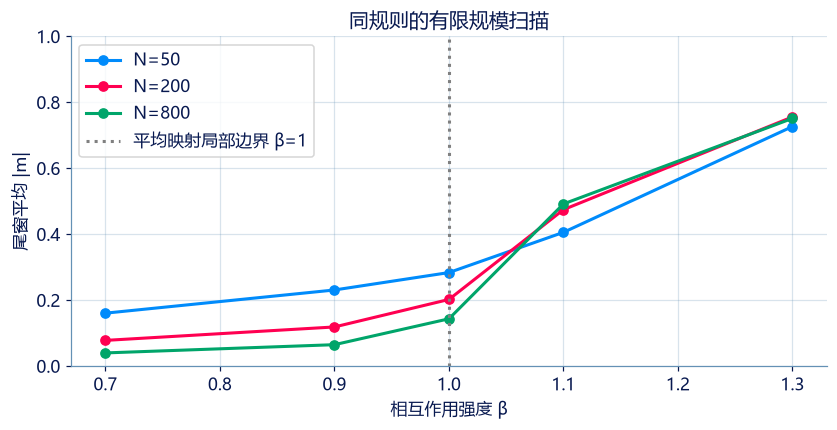

β=1 的重复间标准差： [(50, 0.0696379049796757), (200, 0.03420135946839267), (800, 0.052854135232621634)]


In [4]:
rng=np.random.default_rng(130102)
betas=[.7,.9,1.,1.1,1.3]; sizes=[50,200,800]; scans={}
for n in sizes:
    scans[n]=[]
    for beta in betas:
        paths=[meanfield_path([1]*n,beta,rng.random((120,n))) for _ in range(10)]
        scans[n].append(order_summary(paths,50))
fig,ax=plt.subplots(figsize=(7.5,3.8))
for n,color in zip(sizes,[BLUE,PINK,GREEN]):
    ax.plot(betas,[row[0] for row in scans[n]],marker='o',label=f'N={n}',color=color)
ax.axvline(1,color='gray',ls=':',label='平均映射局部边界 β=1')
ax.set(xlabel='相互作用强度 β',ylabel='尾窗平均 |m|',ylim=(0,1),title='同规则的有限规模扫描')
ax.legend();ax.grid(alpha=.25);plt.show()
print('β=1 的重复间标准差：',[(n,scans[n][2][1]) for n in sizes])

## 结果解释

平均映射的零点斜率恰为 β，但有限 N 的噪声、暂态和扫描网格让观测（observation）曲线平滑。图上虚线是本模型的确定性局部条件，不是从三组模拟独立发现的普适临界指数（critical exponent）。

### 独立核对

用中心差分（central difference）独立核对零点斜率，检查零步和 β=0 的边界。

In [5]:
for beta in [.5,1.,1.3]:
    eps=1e-5
    slope=(math.tanh(beta*eps)-math.tanh(-beta*eps))/(2*eps)
    np.testing.assert_allclose(slope,beta,atol=1e-9)
assert deterministic_meanfield(0.,.4,2)==[.4,0.,0.]
assert deterministic_meanfield(1.2,.4,0)==[.4]
print('固定点斜率和边界核对通过。')

固定点斜率和边界核对通过。


[在本章探索中改变条件](http://127.0.0.1:8000/chapters/13-01-%E7%9B%B8%E5%8F%98%E3%80%81%E4%B8%B4%E7%95%8C%E6%80%A7%E4%B8%8E%E6%9C%89%E9%99%90%E8%A7%84%E6%A8%A1/explore/)：先预测结果，再比较图形与数值。

## 练习与参考资料

先独立作答，再提交核对。

### 第 1 题 · Python 计算题：计算平均场固定点迭代

从 start 出发，重复 m_next=tanh(beta*m)，返回含初值（initial condition）的完整轨迹（trajectory）。此为 N→∞ 条件期望（expectation）映射的确定性参照。

**函数与代码模板**

```python
def solve(
    beta: float,
    start: float,
    steps: int,
) -> list[float]:
    # 按题意计算并返回结果。
    raise NotImplementedError("请完成计算")
```

**参数说明**

| 名称 | Python 类型 | 含义 | 单位 |
|---|---|---|---|
| `beta` | `float` | 相互作用强度，非负。 | 无量纲 |
| `start` | `float` | 初始磁化，介于 -1 与 1。 | 无量纲 |
| `steps` | `int` | 更新次数。 | 步 |

**返回值**

直接返回 path（list[float]）。

| 名称 | Python 类型 | 含义 | 单位 |
|---|---|---|---|
| `path` | `list[float]` | 初值和每一步的平均场磁化。 | 无量纲 |

**计算规则**

每一步只读取上一时刻 m；steps=0 时仅返回初值。

**约束与边界**

- 所有比较使用题定模型（model）和相同单位；仅输出（output）函数返回值，不依赖外部文件。

**输入样例**

每个参数对应函数签名中的同名变量；单位与顺序见下表。

给定条件

| 参数 | 含义 | 给定值 | 单位 |
| --- | --- | --- | --- |
| beta | 相互作用强度，非负。 | 0 | 无量纲 |
| start | 初始磁化，介于 -1 与 1。 | 0.4 | 无量纲 |
| steps | 更新次数。 | 2 | 步 |

**输入与调用代码**

完成 solve 函数后，将下面的参数赋值与调用代码放在函数定义下方运行。

```python
beta = 0.0
start = 0.4
steps = 2

result = solve(beta, start, steps)
print(result)
```

**输出样例**

对这组输入，你的函数应返回下列结果。列表按表格自上而下的顺序排列；标有“≈”的是便于阅读的近似值，请按模型计算完整数值。

计算结果

| 返回项 | 含义 | 结果 | 单位 |
| --- | --- | --- | --- |
| path | 初值和每一步的平均场磁化。 | [0.4, 0.0, 0.0] | 无量纲 |

**预期输出代码**

用 expected_output 对照 result 的类型、顺序与数值。代码保留样例原始精度，浮点结果按题面容差比较。

```python
expected_output = [0.4, 0.0, 0.0]
```

**样例解释**

tanh(0)=0；零步情形不应自行更新。有限随机系统还存在抽样波动。

允许 Python 标准库；绝对误差 1e-08 或相对误差 1e-07。

[作答：计算平均场固定点迭代](http://127.0.0.1:8000/chapters/13-01-%E7%9B%B8%E5%8F%98%E3%80%81%E4%B8%B4%E7%95%8C%E6%80%A7%E4%B8%8E%E6%9C%89%E9%99%90%E8%A7%84%E6%A8%A1/practice/?question=p13-deterministic-meanfield)

### 第 2 题 · 单项选择题：固定点失稳条件

对 m_next=tanh(beta*m)，零固定点（fixed point）附近斜率（slope）为 beta。beta 非负时哪项成立？

- **A.** beta<1 时零点（zero）局部稳定；beta>1 时零点局部不稳定。
- **B.** beta>1 时零点因为 tanh 有界而一定稳定。
- **C.** beta=1 时线性斜率已足以判定严格渐近速度。
- **D.** 有限 N 的模拟阈值严格等于1且没有误差。

[作答：固定点失稳条件](http://127.0.0.1:8000/chapters/13-01-%E7%9B%B8%E5%8F%98%E3%80%81%E4%B8%B4%E7%95%8C%E6%80%A7%E4%B8%8E%E6%9C%89%E9%99%90%E8%A7%84%E6%A8%A1/practice/?question=p13-meanfield-threshold)

### 第 3 题 · 单项选择题：怎样比较三个规模

将 N=50、200、800 的参数（parameter）扫描用于有限规模（finite size）比较时，哪项设计最可解释？

- **A.** 同一更新规则与参数网格，说明暂态（transient）、观察时长、重复数及初态。
- **B.** 每个规模自行更换规则和观测（observation）窗口。
- **C.** 只取每个规模的一条最高曲线。
- **D.** 看到一条近直线就宣布普适指数。

[作答：怎样比较三个规模](http://127.0.0.1:8000/chapters/13-01-%E7%9B%B8%E5%8F%98%E3%80%81%E4%B8%B4%E7%95%8C%E6%80%A7%E4%B8%8E%E6%9C%89%E9%99%90%E8%A7%84%E6%A8%A1/practice/?question=p13-size-comparison)

### 第 4 题 · 单项选择题：分岔与相变语言

同一模型（model）的确定性平均映射在 beta=1 改变零点（zero）稳定性；有限随机曲线随 N 变陡。哪项表述合适？

- **A.** 前者是确定性固定点（fixed point）分岔（bifurcation）证据，后者是有限规模（finite size）现象；热力学极限（thermodynamic limit）仍需论证。
- **B.** 任一有限曲线自动证明连续相变。
- **C.** 平均映射的稳定性与随机模型毫无关系。
- **D.** 绝对磁化不可能用于描述序参量（order parameter）。

[作答：分岔与相变语言](http://127.0.0.1:8000/chapters/13-01-%E7%9B%B8%E5%8F%98%E3%80%81%E4%B8%B4%E7%95%8C%E6%80%A7%E4%B8%8E%E6%9C%89%E9%99%90%E8%A7%84%E6%A8%A1/practice/?question=p13-critical-language)

**进一步阅读**

[SFI Complexity Explorer 复杂系统课程](https://www.complexityexplorer.org/courses/185-introduction-to-complexity/faq)提供复杂系统与集体现象的进一步阅读。